<a href="https://colab.research.google.com/github/aj11anuj/optimly/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The objective of the content action playbook is to translate validated model outputs into a practical, prioritized queue of content actions. Each recommendation is associated with a reason code, an action, and a human-review requirement. Actions are prioritized using the validated baseline model score, observed content performance, and data quality indicators. The score is used for decision support, not as a direct estimate of the impact of an intervention.

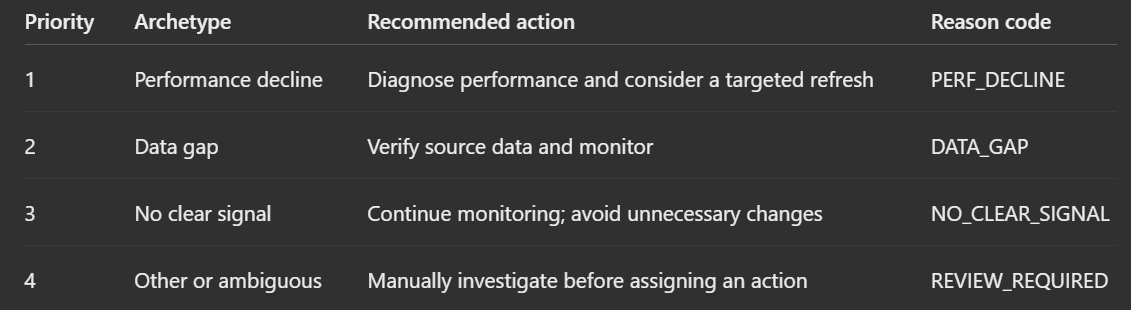

### Reason codes:
*   **PERF_DECLINE**: Observed performance deterioration warrants investigation, but does not establish that a content change will improve results.
*   **DATA_GAP**: Missing, stale, or incomplete measurements make a reliable content decision difficult.
*   **NO_CLEAR_SIGNAL**: Available evidence does not justify a specific intervention.
*   **REVIEW_REQUIRED**: Conflicting signals, unusual observations, or unsupported cases require manual assessment.

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load actual W05 model dataset
DATA_PATH = "/content/w05_model_data.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Available columns:", df.columns.tolist())

# Actual columns in your dataset
SCORE_COL = "w04_baseline_score"

# Check required columns
required = [
    "underperformer",
    "gsc_data_available",
    "ga4_data_available",
    SCORE_COL,
    "content_hash_id"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Normalize relevant flags
for col in [
    "underperformer",
    "gsc_data_available",
    "ga4_data_available"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Derive archetypes from observed flags.
# Data availability takes precedence because unreliable
# measurements should be verified before performance diagnosis.
df["archetype"] = np.select(
    [
        (
            df["gsc_data_available"].ne(1)
            | df["ga4_data_available"].ne(1)
        ),
        df["underperformer"].eq(1)
    ],
    [
        "data_gap",
        "performance_concern"
    ],
    default="no_clear_signal"
)

# Define candidate actions and reason codes
ACTION_MAP = {
    "data_gap": {
        "priority": 1,
        "reason_code": "DATA_GAP",
        "action": "Verify measurement coverage and monitor",
        "review": "Required before interpreting performance"
    },
    "performance_concern": {
        "priority": 2,
        "reason_code": "PERF_CONCERN",
        "action": "Investigate underperformance; consider refresh",
        "review": "Required before any content change"
    },
    "no_clear_signal": {
        "priority": 3,
        "reason_code": "NO_CLEAR_SIGNAL",
        "action": "Continue monitoring; avoid unnecessary changes",
        "review": "Periodic review"
    }
}

# Map archetypes to actions
for field in ["priority", "reason_code", "action", "review"]:
    df[field] = df["archetype"].map(
        {key: value[field] for key, value in ACTION_MAP.items()}
    )

df = df.rename(columns={
    "action": "recommended_action",
    "review": "human_review"
})

# Ensure score is numeric, but don't assume its direction
df[SCORE_COL] = pd.to_numeric(
    df[SCORE_COL], errors="coerce"
)

# Rank by priority, then underperformer flag.
# Keep W04 score for interpretation, not ranking, until
# its precise meaning and direction are verified.
df = df.sort_values(
    ["priority", "underperformer"],
    ascending=[True, False],
    na_position="last"
).reset_index(drop=True)

df.insert(0, "queue_rank", np.arange(1, len(df) + 1))

# Require human approval for all recommendations
df["requires_human_approval"] = True
df["review_status"] = "Pending human review"

# Mark records with missing critical flags for investigation
invalid_flags = (
    df["underperformer"].isna()
    | df["gsc_data_available"].isna()
    | df["ga4_data_available"].isna()
)

df["no_go_reason"] = np.where(
    invalid_flags,
    "Missing or invalid classification flags",
    ""
)

df.loc[invalid_flags, "review_status"] = "Hold - investigate"
df["no_go"] = invalid_flags

# Inspect ranked queue
display(
    df[[
        "queue_rank",
        "content_hash_id",
        "archetype",
        "priority",
        "reason_code",
        "recommended_action",
        SCORE_COL,
        "human_review",
        "review_status",
        "no_go"
    ]].head(15)
)

# Summarize archetypes
summary = (
    df.groupby(
        ["archetype", "priority", "reason_code",
         "recommended_action"],
        dropna=False
    )
    .agg(
        content_count=("content_hash_id", "count"),
        no_go_count=("no_go", "sum")
    )
    .reset_index()
    .sort_values("priority")
)

summary["share_pct"] = (
    summary["content_count"] / len(df) * 100
).round(2)

display(summary)

# Export results
OUTPUT_DIR = Path("work/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(
    OUTPUT_DIR / "w07_ranked_action_queue.csv",
    index=False
)

summary.to_csv(
    OUTPUT_DIR / "w07_archetype_action_summary.csv",
    index=False
)

print("Exported ranked queue and archetype summary.")

Dataset shape: (9350, 32)
Available columns: ['client_hash_id', 'content_hash_id', 'underperformer', 'w04_baseline_score', 'impressions', 'log_impressions', 'avg_position', 'position_bucket', 'clicks', 'actual_ctr', 'peer_ctr', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_seconds', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta']


,queue_rank,content_hash_id,archetype,priority,reason_code,recommended_action,w04_baseline_score,human_review,review_status,no_go
0,1,content_ebca888f934d1eee,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,2.267814,Required before interpreting performance,Pending human review,False
1,2,content_213f821cd577e45c,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.086892,Required before interpreting performance,Pending human review,False
2,3,content_d18f5f0b17ec58eb,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.564062,Required before interpreting performance,Hold - investigate,True
3,4,content_ad2f848ecf84dfe4,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.257573,Required before interpreting performance,Pending human review,False
4,5,content_753cc3bcc3071b8b,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.549284,Required before interpreting performance,Pending human review,False
5,6,content_9df3f79068d3777b,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,1.600583,Required before interpreting performance,Hold - investigate,True
6,7,content_54f809776d779391,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,3.882320,Required before interpreting performance,Hold - investigate,True
7,8,content_1820f113e04fe827,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.034136,Required before interpreting performance,Pending human review,False
8,9,content_b546163ac9b68bf1,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.034136,Required before interpreting performance,Pending human review,False
9,10,content_966effc8f2d8afee,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,0.034136,Required before interpreting performance,Pending human review,False


,archetype,priority,reason_code,recommended_action,content_count,no_go_count,share_pct
0,data_gap,1,DATA_GAP,Verify measurement coverage and monitor,5005,2174,53.53
2,performance_concern,2,PERF_CONCERN,Investigate underperformance; consider refresh,2612,0,27.94
1,no_clear_signal,3,NO_CLEAR_SIGNAL,Continue monitoring; avoid unnecessary changes,1733,0,18.53


Exported ranked queue and archetype summary.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The playbook is intended for content strategists, editors, SEO analysts, and research teams evaluating data-driven content maintenance workflows. It helps users:

*   Identify content items that warrant investigation.
*   Distinguish performance concerns from data-quality issues.
*   Associate content archetypes with candidate actions.
*   Allocate limited editorial resources to items with stronger evidence or greater urgency.
*   Maintain a record of recommendations and subsequent human decisions.











Content performance is time dependent. A previously successful page may experience declining traffic or engagement as user interests, search behavior, competing content, and information freshness change. However, an observed decline is not sufficient evidence that refreshing a page will improve its performance. Changes in seasonality, search engine behavior, measurement coverage, and external demand may also explain the decline.

In [7]:
print("Dataset overview")
print("-" * 40)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Unique archetypes: {df[ARCHETYPE_COL].nunique()}")

print("\nArchetype distribution")
display(
    df[ARCHETYPE_COL]
    .value_counts(dropna=False)
    .rename_axis("archetype")
    .reset_index(name="content_count")
)

quality_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (
        df.isna().mean().values * 100
    ).round(2),
    "unique_values": [
        df[col].nunique(dropna=True)
        for col in df.columns
    ]
})

display(
    quality_summary.sort_values(
        "missing_pct", ascending=False
    ).head(20)
)

numeric_summary = df.select_dtypes(
    include="number"
).describe().T
display(numeric_summary)

Dataset overview
----------------------------------------
Rows: 9,350
Columns: 42
Unique archetypes: 3

Archetype distribution


,archetype,content_count
0,data_gap,5005
1,performance_concern,2612
2,no_clear_signal,1733


,column,missing_count,missing_pct,unique_values
23,sessions_referral,2174,23.25,12
24,sessions_social,2174,23.25,6
18,ga4_users,2174,23.25,224
19,ga4_engaged_sessions,2174,23.25,21
20,ga4_total_engagement_seconds,2174,23.25,464
21,sessions_organic,2174,23.25,134
22,sessions_direct,2174,23.25,41
15,ga4_data_available,2174,23.25,2
17,ga4_sessions,2174,23.25,231
16,ga4_pageviews,2174,23.25,245


,count,mean,std,min,25%,50%,75%,max
queue_rank,9350.0,4675.500000,2699.256842,1.000000,2338.250000,4675.500000,7012.750000,9350.000000
underperformer,9350.0,0.757540,0.428594,0.000000,1.000000,1.000000,1.000000,1.000000
w04_baseline_score,9350.0,-0.519196,10.657225,-279.108147,0.002698,0.089995,0.608358,194.410484
impressions,9350.0,1194.590374,3682.661728,1.000000,36.000000,216.000000,953.750000,143907.000000
log_impressions,9350.0,5.227683,2.162415,0.693147,3.610918,5.379897,6.861449,11.876929
avg_position,9350.0,14.120563,6.375995,8.178409,8.473809,8.768568,21.155647,22.428571
position_bucket,9350.0,3.438075,0.496177,3.000000,3.000000,3.000000,4.000000,4.000000
clicks,9350.0,3.092299,12.521426,0.000000,0.000000,0.000000,2.000000,315.000000
actual_ctr,9350.0,0.003130,0.019994,0.000000,0.000000,0.000000,0.002066,1.000000
peer_ctr,9350.0,0.002335,0.000870,0.001344,0.001349,0.003103,0.003103,0.003108


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

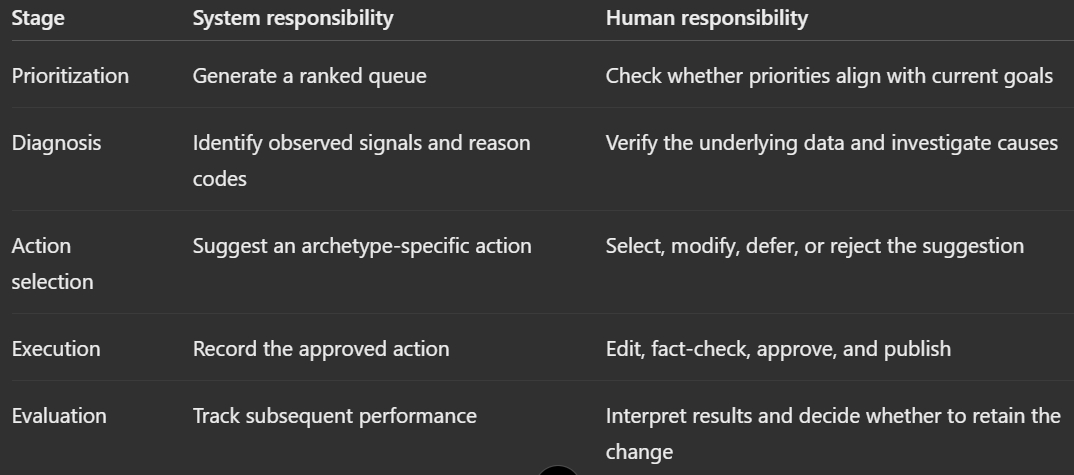

### What should not be automated:
1. Publishing or modifying content without editorial approval.
2. Deleting, redirecting, or consolidating pages solely on the basis of a model score.
3. Making factual, medical, financial, legal, or safety sensitive claims without qualified review.
4. Changing canonical URLs, internal linking architecture, or indexing directives automatically.
5. Automatically increasing the priority of content solely because of a potentially anomalous metric.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Model retraining or recalibration should be considered when:
1.   Data distributions shift persistently beyond expected variation.
2.   Model performance on an appropriate, independently evaluated sample deteriorates.
3.  The content population or business objective changes materially.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

A content item with a strong performance signal may still be a low priority intervention if the required work is expensive, the evidence is weak, or the page has limited strategic relevance. The notebook produces the following reproducible outputs under work/outputs/:
1.  w07_ranked_action_queue.csv: item-level recommendations, ranks, reason codes, review status, and candidate actions.
2.  w07_archetype_action_summary.csv: aggregated archetype counts, priority distribution, and action mapping.
3.  w07_monitoring_summary.csv: lightweight monitoring metrics and review indicators.

The proposed workflow requires prospective evaluation before any claims can be made about editorial efficiency, traffic improvement, or business impact.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.